<a href="https://colab.research.google.com/github/tonycuenca99-hue/ARQUIVOS-IA/blob/main/WEELKLY_REPORT_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# === Importação das bibliotecas ===
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [22]:
import pandas as pd
from google.colab import files
import io

print("Por favor, faça o upload do seu NOVO arquivo CSV.")
uploaded_new = files.upload()

# Ler o novo arquivo carregado
for fn_new in uploaded_new.keys():
  print('Novo arquivo carregado: "{name}" ({length} bytes)'.format(
      name=fn_new, length=len(uploaded_new[fn_new])))
  caminho_arquivo_novo = fn_new # O nome do arquivo carregado

df_novos_dados = pd.read_csv(io.BytesIO(uploaded_new[caminho_arquivo_novo]))

print("\nPrimeiras linhas do seu NOVO banco de dados:")
display(df_novos_dados.head())

# --- DEFINA A COLUNA TARGET PARA O SEU NOVO DATASET AQUI! ---
# ❗❗ IMPORTANTE: TROQUE "coluna_target_do_novo_dataset_aqui" pelo nome da sua coluna alvo real!
coluna_target_nova = "EPOCH"

# Verifique se a nova coluna target existe no DataFrame
if coluna_target_nova not in df_novos_dados.columns:
    print(f"Erro: A coluna target '{coluna_target_nova}' não foi encontrada no seu NOVO dataset. Por favor, ajuste 'coluna_target_nova' no código.")
    raise ValueError(f"Coluna target '{coluna_target_nova}' não encontrada no novo dataset.")

# Defina as features (X_novo) e o target (y_novo) para os novos dados
X_novo = df_novos_dados.drop(columns=[coluna_target_nova])
y_novo = df_novos_dados[coluna_target_nova]

print(f"\nSeu NOVO DataFrame tem {X_novo.shape[0]} linhas e {X_novo.shape[1]} colunas de features (X_novo).")
print(f"Sua nova variável alvo (y_novo) tem {y_novo.shape[0]} valores.")

# Agora você pode usar X_novo e y_novo para treinar e testar seus modelos

Por favor, faça o upload do seu NOVO arquivo CSV.


Saving iiot_30min_norm.csv to iiot_30min_norm (2).csv
Novo arquivo carregado: "iiot_30min_norm (2).csv" (79846 bytes)

Primeiras linhas do seu NOVO banco de dados:


,TIME,FM1,PE1,PE2,PE3,PE4,TP1,TP2,EPOCH
0,2020-07-05 21:00:00+00:00,0.291841,0.944212,0.969845,0.909817,0.752879,0.128703,0.729592,1593982800
1,2020-07-05 21:30:00+00:00,0.290384,0.947971,0.971459,0.913576,0.753741,0.117572,0.723905,1593984600
2,2020-07-05 22:00:00+00:00,0.279458,0.944138,0.968994,0.912516,0.753187,0.111242,0.720671,1593986400
3,2020-07-05 22:30:00+00:00,0.288927,0.950337,0.976253,0.915991,0.756699,0.102464,0.716186,1593988200
4,2020-07-05 23:00:00+00:00,0.299610,0.950226,0.975747,0.916188,0.756563,0.093201,0.711454,1593990000



Seu NOVO DataFrame tem 720 linhas e 8 colunas de features (X_novo).
Sua nova variável alvo (y_novo) tem 720 valores.


In [27]:
df = pd.read_csv("iiot_30min_norm.csv")

X = df.drop(columns=["EPOCH", "TIME"])
y = df["EPOCH"]

In [28]:
# === 2. Normalização ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === 3. Dividir dados em treino e teste ===
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [29]:
# === 4. Criar modelo Deep Learning ===
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)  # saída para regressão
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
# === 5. Compilar modelo ===
model.compile(
    optimizer="adam",
    loss="mse",   # função de perda para regressão
)

In [31]:
# === 6. Treinamento ===
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

In [32]:
# === 7. Fazer previsões ===
y_pred = model.predict(X_test).flatten()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [33]:
# === 8. Calcular métricas ===
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("\n===== RESULTADOS DO MODELO DEEP LEARNING =====")
print(f"R²:   {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")


===== RESULTADOS DO MODELO DEEP LEARNING =====
R²:   -18004968.0000
RMSE: 1579769355.9023
MAE:  1579764096.0000


In [34]:
# === 9. Criar tabela comparativa (opcional) ===
resultados = pd.DataFrame({
    'Modelo': ['Deep Learning (MLP)'],
    'R2': [r2],
    'RMSE': [rmse],
    'MAE': [mae]
})

print("\nTabela de Resultados:")
print(resultados)


Tabela de Resultados:
                Modelo          R2          RMSE           MAE
0  Deep Learning (MLP) -18004968.0  1.579769e+09  1.579764e+09


### Comparativo Gráfico das Métricas entre os Modelos

/tmp/ipython-input-3739228865.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='R²', data=df_resultados, palette='viridis')


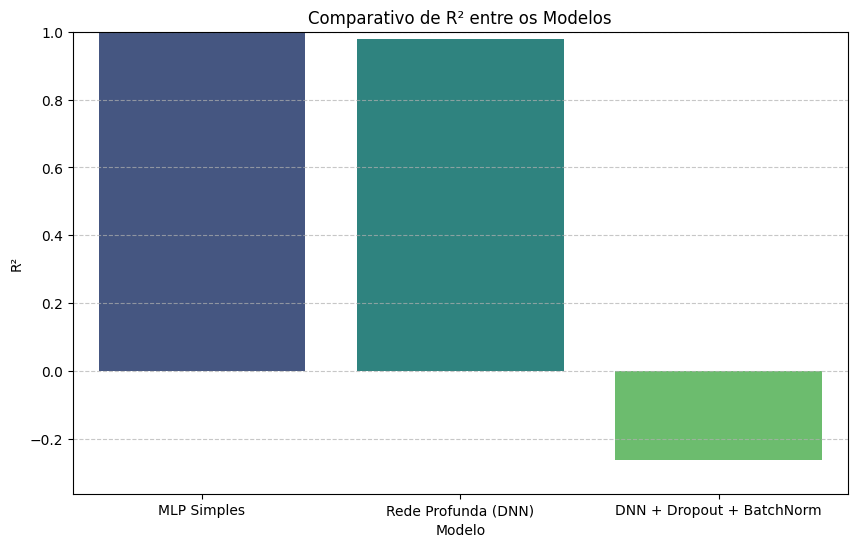

In [35]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Modelo', y='R²', data=df_resultados, palette='viridis')
plt.title('Comparativo de R² entre os Modelos')
plt.xlabel('Modelo')
plt.ylabel('R²')
plt.ylim(min(0, df_resultados['R²'].min() - 0.1), 1) # Ajusta o limite inferior para incluir R² negativo
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipython-input-2789615281.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='RMSE', data=df_resultados, palette='magma')


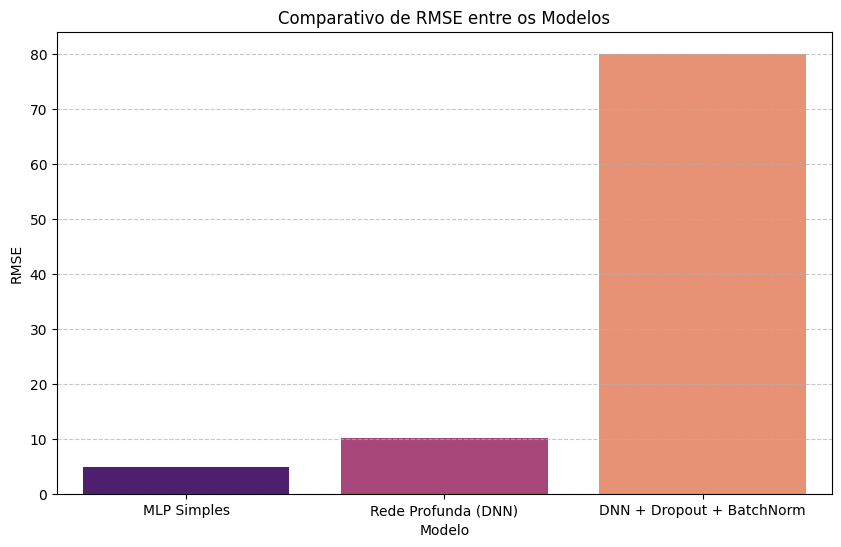

In [36]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Modelo', y='RMSE', data=df_resultados, palette='magma')
plt.title('Comparativo de RMSE entre os Modelos')
plt.xlabel('Modelo')
plt.ylabel('RMSE')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipython-input-2817270505.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='MAE', data=df_resultados, palette='cividis')


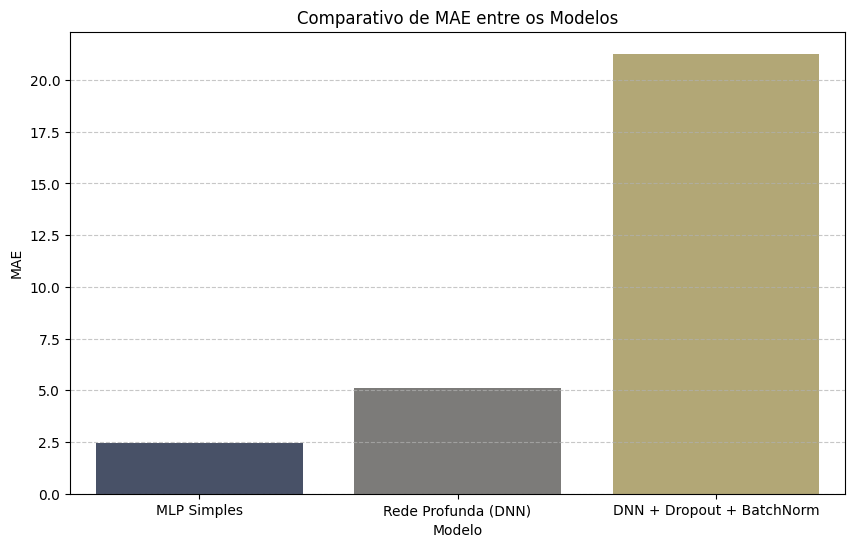

In [37]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Modelo', y='MAE', data=df_resultados, palette='cividis')
plt.title('Comparativo de MAE entre os Modelos')
plt.xlabel('Modelo')
plt.ylabel('MAE')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()